<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/ZTF_candidates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors

In [ ]:
!pip -q install msal requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
!pip install astroquery astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.1 MB/s eta 0:00:00


In [ ]:
!pip install alerce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00


In [ ]:
!pip -q install alerce astropy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alerce.core import Alerce
from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u



In [ ]:
client = Alerce()

cls = client.query_classifiers(format="pandas", survey="ztf")

print(cls.columns)
display(cls.head(20))


Index(['classifier_name', 'classifier_version', 'classes'], dtype='object')


,classifier_name,classifier_version,classes
0,lc_classifier_transient,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN]"
1,lc_classifier_stochastic,hierarchical_random_forest_1.0.0,"[QSO, AGN, Blazar, CV/Nova, YSO]"
2,lc_classifier_periodic,hierarchical_random_forest_1.0.0,"[LPV, E, DSCT, RRL, CEP, Periodic-Other]"
3,LC_classifier_ATAT_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
4,LC_classifier_BHRF_forced_phot(beta),beta,"[SNIa, SNIbc, SNIIb, SNII, SNIIn, SLSN, TDE, M..."
5,lc_classifier,hierarchical_random_forest_1.0.0,"[SNIa, SNIbc, SNII, SLSN, QSO, AGN, Blazar, CV..."
6,lc_classifier_top,hierarchical_random_forest_1.0.0,"[Transient, Stochastic, Periodic]"
7,stamp_classifier,stamp_classifier_1.0.0,"[SN, AGN, VS, asteroid, bogus]"
8,stamp_classifier,stamp_classifier_1.0.4,"[SN, AGN, VS, asteroid, bogus]"
9,lc_classifier_BHRF_forced_phot,2.1.0,"[SNIa, SESN, SNII, SNIIn, SLSN, TDE, Microlens..."


In [ ]:
client = Alerce()

#1 Sept 2025
START_MJD = 60918

df = client.query_objects(
    survey="ztf",
    classifier="lc_classifier_BHRF_forced_phot",
    class_name="SNIa",
    probability=0.59,
    order_by="lastmjd",
    order_mode="DESC",
    page_size=2000,
    format="pandas"
)

df["lastmjd"] = pd.to_numeric(df["lastmjd"], errors="coerce")

# filtrar
df_snia = df[df["lastmjd"] >= START_MJD]

print("SNIa encontradas:", len(df_snia))

display(df_snia)

SNIa encontradas: 129


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF25acldfsf,62,1931,61038.504873,61110.521099,False,False,59,None,None,...,61110.521099,72.016227,218.473269,5.460064,0.002802,0.002789,SNIa,lc_classifier_BHRF_forced_phot,0.620800,27.5.7a32.dev1
1,ZTF26aabkqap,33,879,61055.553206,61110.481134,False,False,33,None,None,...,61110.481134,54.927928,203.263061,-16.241590,0.003582,0.003439,SNIa,lc_classifier_BHRF_forced_phot,0.695024,27.5.7a32.dev1
2,ZTF26aaaehuj,66,1212,61050.377141,61110.453426,False,False,61,None,None,...,61110.453426,60.076285,155.604512,4.000440,0.002901,0.002894,SNIa,lc_classifier_BHRF_forced_phot,0.716584,27.5.7a32.dev1
3,ZTF26aadonog,38,929,61061.501713,61110.419190,True,False,34,None,None,...,61110.419190,48.917477,195.152333,-6.474194,0.003675,0.003651,SNIa,lc_classifier_BHRF_forced_phot,0.640692,27.5.7a32.dev1
4,ZTF26aadsezg,119,2962,61065.412280,61110.396088,False,False,56,None,None,...,61110.396088,44.983808,184.384761,13.836323,0.003122,0.003031,SNIa,lc_classifier_BHRF_forced_phot,0.728540,27.5.7a32.dev1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,ZTF25aascfmn,91,3363,60821.330197,60922.207419,False,False,68,None,None,...,60922.207419,100.877222,276.762999,51.053522,0.014309,0.008995,SNIa,lc_classifier_BHRF_forced_phot,0.760000,27.5.6
125,ZTF25abbshoi,37,2136,60873.239514,60920.172257,False,False,39,None,None,...,60920.172257,46.932743,283.543081,41.295738,0.015511,0.011654,SNIa,lc_classifier_BHRF_forced_phot,0.718000,27.5.6
126,ZTF25abcfyxt,108,1792,60875.399525,60919.353299,False,False,99,None,None,...,60919.353299,42.931771,348.134379,-0.207635,0.003053,0.003053,SNIa,lc_classifier_BHRF_forced_phot,0.746000,27.5.6
127,ZTF25aatvtvy,56,1572,60831.383391,60919.350475,False,False,39,None,None,...,60919.350475,87.967083,349.269353,18.599774,0.012550,0.011894,SNIa,lc_classifier_BHRF_forced_phot,0.641712,27.5.6


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tns_public_objects.csv to tns_public_objects.csv


In [ ]:
tns = pd.read_csv("tns_public_objects.csv", skiprows=1, low_memory=False)

#print("\nColumnas TNS:")
#print(tns.columns.tolist())


tns["ra"] = pd.to_numeric(tns["ra"], errors="coerce")
tns["declination"] = pd.to_numeric(tns["declination"], errors="coerce")
tns["redshift"] = pd.to_numeric(tns["redshift"], errors="coerce")

tns = tns.dropna(subset=["ra", "declination"]).reset_index(drop=True)

#print("Objetos en TNS:", len(tns))
#display(tns.head())

# Cambbio de coordenadas
coords_snia = SkyCoord(
    ra=df_snia["meanra"].values * u.deg,
    dec=df_snia["meandec"].values * u.deg
)

coords_tns = SkyCoord(
    ra=tns["ra"].values * u.deg,
    dec=tns["declination"].values * u.deg
)

#match
idx, sep2d, _ = coords_snia.match_to_catalog_sky(coords_tns)

# umbral de matching
max_sep = 2.0 * u.arcsec
matched = sep2d <= max_sep


df_snia["tns_match"] = matched
df_snia["tns_sep_arcsec"] = sep2d.arcsec

df_snia["tns_name"] = np.where(
    matched,
    tns.iloc[idx]["name"].values,
    None
)

df_snia["tns_name_prefix"] = np.where(
    matched,
    tns.iloc[idx]["name_prefix"].values,
    None
)

df_snia["tns_type"] = np.where(
    matched,
    tns.iloc[idx]["type"].values,
    None
)

df_snia["tns_redshift"] = np.where(
    matched,
    tns.iloc[idx]["redshift"].values,
    np.nan
)

df_snia["tns_full_name"] = np.where(
    matched,
    df_snia["tns_name_prefix"].astype(str) + " " + df_snia["tns_name"].astype(str),
    None
)

print("\nMatches encontrados:", int(df_snia["tns_match"].sum()))
display(df_snia.head())


output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print(f"\n Guardado: {output_file}")


Matches encontrados: 129


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,classifier,probability,step_id_corr,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name
0,ZTF25acldfsf,62,1931,61038.504873,61110.521099,False,False,59,None,None,...,lc_classifier_BHRF_forced_phot,0.620800,27.5.7a32.dev1,True,0.099630,2025ajnc,SN,SN Ia,0.024931,SN 2025ajnc
1,ZTF26aabkqap,33,879,61055.553206,61110.481134,False,False,33,None,None,...,lc_classifier_BHRF_forced_phot,0.695024,27.5.7a32.dev1,True,0.087776,2026amc,SN,SN Ia,0.024107,SN 2026amc
2,ZTF26aaaehuj,66,1212,61050.377141,61110.453426,False,False,61,None,None,...,lc_classifier_BHRF_forced_phot,0.716584,27.5.7a32.dev1,True,0.106173,2026kc,SN,SN Ia,0.022800,SN 2026kc
3,ZTF26aadonog,38,929,61061.501713,61110.419190,True,False,34,None,None,...,lc_classifier_BHRF_forced_phot,0.640692,27.5.7a32.dev1,True,0.047164,2026azd,SN,SN Ia-91T-like,0.015600,SN 2026azd
4,ZTF26aadsezg,119,2962,61065.412280,61110.396088,False,False,56,None,None,...,lc_classifier_BHRF_forced_phot,0.728540,27.5.7a32.dev1,True,0.154113,2026bhf,SN,SN Ia,0.065142,SN 2026bhf



 Guardado: df_snia_with_tns_match.csv


In [ ]:
from google.colab import files
files.download("df_snia_with_tns_match.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TABLA COMPLETA

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(df_snia)

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,g_r_mean,g_r_mean_corr,firstmjd,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr,tns_match,tns_sep_arcsec,tns_name,tns_name_prefix,tns_type,tns_redshift,tns_full_name
0,ZTF25acldfsf,62,1931,61038.504873,61110.521099,False,False,59,None,None,None,None,61038.504873,61110.521099,72.016227,218.473269,5.460064,0.002802,0.002789,SNIa,lc_classifier_BHRF_forced_phot,0.620800,27.5.7a32.dev1,True,0.099630,2025ajnc,SN,SN Ia,0.024931,SN 2025ajnc
1,ZTF26aabkqap,33,879,61055.553206,61110.481134,False,False,33,None,None,None,None,61055.553206,61110.481134,54.927928,203.263061,-16.241590,0.003582,0.003439,SNIa,lc_classifier_BHRF_forced_phot,0.695024,27.5.7a32.dev1,True,0.087776,2026amc,SN,SN Ia,0.024107,SN 2026amc
2,ZTF26aaaehuj,66,1212,61050.377141,61110.453426,False,False,61,None,None,None,None,61050.377141,61110.453426,60.076285,155.604512,4.000440,0.002901,0.002894,SNIa,lc_classifier_BHRF_forced_phot,0.716584,27.5.7a32.dev1,True,0.106173,2026kc,SN,SN Ia,0.022800,SN 2026kc
3,ZTF26aadonog,38,929,61061.501713,61110.419190,True,False,34,None,None,None,None,61061.501713,61110.419190,48.917477,195.152333,-6.474194,0.003675,0.003651,SNIa,lc_classifier_BHRF_forced_phot,0.640692,27.5.7a32.dev1,True,0.047164,2026azd,SN,SN Ia-91T-like,0.015600,SN 2026azd
4,ZTF26aadsezg,119,2962,61065.412280,61110.396088,False,False,56,None,None,None,None,61065.412280,61110.396088,44.983808,184.384761,13.836323,0.003122,0.003031,SNIa,lc_classifier_BHRF_forced_phot,0.728540,27.5.7a32.dev1,True,0.154113,2026bhf,SN,SN Ia,0.065142,SN 2026bhf
5,ZTF26aaenpqj,48,1499,61072.335567,61110.380301,False,False,46,None,None,None,None,61072.335567,61110.380301,38.044734,163.454584,9.227690,0.003101,0.003061,SNIa,lc_classifier_BHRF_forced_phot,0.626000,27.5.7a32.dev1,True,0.137427,2026buk,SN,SN Ia-91T-like,0.063695,SN 2026buk
6,ZTF26aaebmad,40,814,61068.395949,61110.357998,False,False,40,None,None,None,None,61068.395949,61110.357998,41.962049,182.427722,-7.467115,0.003266,0.003238,SNIa,lc_classifier_BHRF_forced_phot,0.625124,27.5.7a32.dev1,True,0.131956,2026bmo,SN,SN Ia,0.052000,SN 2026bmo
7,ZTF26aafqpqd,40,1310,61079.277813,61108.402581,False,False,32,None,None,None,None,61079.277813,61108.402581,29.124768,160.139402,2.489350,0.003661,0.003658,SNIa,lc_classifier_BHRF_forced_phot,0.593616,27.5.7a32.dev1,True,0.237297,2026cli,SN,SN Ia,0.081540,SN 2026cli
8,ZTF26aabjpnx,100,2021,61055.411100,61108.278403,True,False,67,None,None,None,None,61056.297303,61108.278403,51.981100,144.567299,26.688919,0.002802,0.002503,SNIa,lc_classifier_BHRF_forced_phot,0.620052,27.5.7a32.dev1,True,0.166178,2026akn,SN,SN Ia,0.043354,SN 2026akn
9,ZTF26aaczrao,74,1534,61060.285660,61108.275069,False,False,69,None,None,None,None,61060.317025,61108.275069,47.958044,120.552522,-4.239009,0.002586,0.002579,SNIa,lc_classifier_BHRF_forced_phot,0.807488,27.5.7a32.dev1,True,0.010474,2026auh,SN,SN Ia,0.034000,SN 2026auh


In [ ]:
output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print("Archivo guardado:", output_file)

from google.colab import files
files.download("df_snia_with_tns_match.csv")

Archivo guardado: df_snia_with_tns_match.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LIGHT CURVES

In [ ]:
import os

client = Alerce()

outdir = "lightcurves_snia"
os.makedirs(outdir, exist_ok=True)

all_lcs = []

for oid in df_snia["oid"]:
    try:
        det = client.query_detections(oid, format="pandas")

        forced = client.query_non_detections(oid, format="pandas")

        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid

            det.to_csv(f"{outdir}/{oid}_detections.csv", index=False)

            all_lcs.append(det)

        else:
            print(f"Sin detections para {oid}")

    except Exception as e:
        print(f"Error con {oid}: {e}")

if len(all_lcs) > 0:
    df_all_lcs = pd.concat(all_lcs, ignore_index=True)
    output_file = "all_snia_lightcurves.csv"
    df_all_lcs.to_csv(output_file, index=False)

    print(f"Total filas: {len(df_all_lcs)}")
else:
    print("No se pudo descargar ninguna curva de luz")

Total filas: 5903


In [ ]:
from google.colab import files
files.download("all_snia_lightcurves.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
oid_selected = "ZTF25abqamzb"

det = client.query_detections(oid_selected, format="pandas")

if det is not None and len(det) > 0:
    det = det.copy()
    det["oid"] = oid_selected

    output_file = f"{oid_selected}_lightcurve.csv"
    det.to_csv(output_file, index=False)

    print(f"Curva de luz guardada: {output_file}")
    print(f"Total puntos: {len(det)}")
    display(det.head())
else:
    print(f"No se encontraron detections para {oid_selected}")

Curva de luz guardada: ZTF25abqamzb_lightcurve.csv
Total puntos: 34


,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magpsf_corr,magap,sigmapsf,sigmapsf_corr,sigmapsf_corr_ext,sigmagap,ra,dec,rb,rbversion,magapbig,sigmagapbig,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,drb,rfid,oid
0,ztf,60927.302569,3173302560315015007,2,3173302560315,19.424500,1,3173,0.611944,19.711100,18.871763,19.2999,0.305463,0.138712,0.141002,0.3548,11.660647,29.897608,0.684286,t17_f5_c3,19.1430,0.3942,False,True,False,27.5.6,0.0,3.201356e+18,NaN,NaN,ZTF25abqamzb
1,ztf,60929.342535,3175342530315015009,1,3175342530315,19.249200,1,3175,0.859849,19.780500,19.203655,19.7301,0.302916,0.176671,0.178067,0.5493,11.660559,29.897567,0.608571,t17_f5_c3,19.2475,0.4527,False,True,False,27.5.6,0.0,3.201356e+18,NaN,NaN,ZTF25abqamzb
2,ztf,60929.366458,3175366450315015007,2,3175366450315,19.510410,1,3175,0.655828,19.452790,18.744862,20.0699,0.215680,0.110089,0.112367,0.7297,11.660587,29.897639,0.690000,t17_f5_c3,19.7902,0.7241,True,True,False,27.5.6,0.0,NaN,0.999499,649120203.0,ZTF25abqamzb
3,ztf,60933.282419,3179282410315015012,1,3179282410315,20.537329,1,3179,0.681314,18.887619,18.596043,18.8098,0.077763,0.058072,0.059449,0.0777,11.660605,29.897602,0.957143,t17_f5_c3,18.7954,0.0970,True,True,False,27.5.6,0.0,NaN,1.000000,649120103.0,ZTF25abqamzb
4,ztf,60933.369294,3179369290315015003,2,3179369290315,20.269339,1,3179,0.732289,18.797363,18.355152,18.9009,0.088631,0.056845,0.058980,0.1102,11.660601,29.897601,0.955714,t17_f5_c3,18.8254,0.1307,True,True,False,27.5.6,0.0,NaN,1.000000,649120203.0,ZTF25abqamzb


In [ ]:
# CON ESTO DESCARGAS
from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_204/1555378965.py:26: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)
/tmp/ipykernel_204/1555378965.py:59: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)


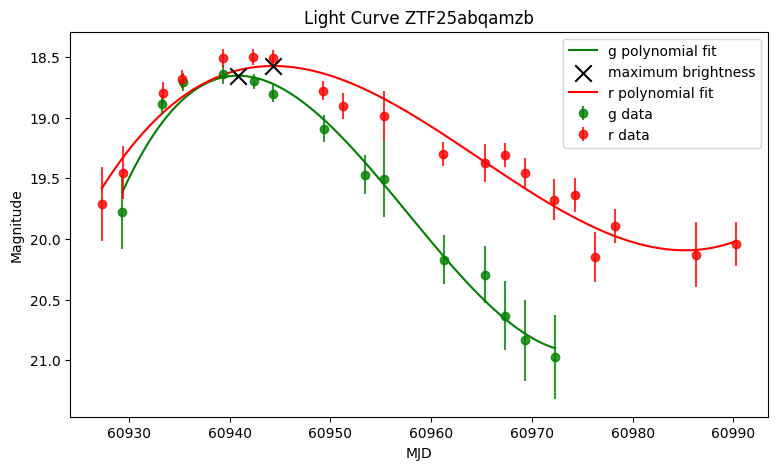

In [ ]:
g = det[det["fid"] == 1].copy()
r = det[det["fid"] == 2].copy()

plt.figure(figsize=(9,5))

plt.errorbar(
    g["mjd"], g["magpsf"], yerr=g["sigmapsf"],
    fmt="o", color="green", label="g data",
    alpha=0.8, zorder=2
)

plt.errorbar(
    r["mjd"], r["magpsf"], yerr=r["sigmapsf"],
    fmt="o", color="red", label="r data",
    alpha=0.8, zorder=2
)

deg = 5

# g
if len(g) > deg:

    x = g["mjd"].values
    y = g["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="green",
        label="g polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_g = xfit[i]
    y_max_g = yfit[i]

    plt.scatter(
        x_max_g, y_max_g,
        color="black",
        marker="x",
        s=140,
        zorder=5,
        label="maximum brightness"
    )


# r
if len(r) > deg:

    x = r["mjd"].values
    y = r["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="red",
        label="r polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_r = xfit[i]
    y_max_r = yfit[i]

    plt.scatter(
        x_max_r, y_max_r,
        color="black",
        marker="x",
        s=140,
        zorder=5
    )


plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(f"Light Curve {oid_selected}")

plt.legend()
plt.show()

# CAMBIO DE MAGNITUDES



In [ ]:
V = r + 0.44 * (g - r) - 0.02
V = B - 1.04*(g-r) - 0.19

r  = B - 1.48*(g-r) - 0.17


http://www.aerith.net/astro/color_conversion.html (NOT SURE)

NameError: name 'B' is not defined

In [ ]:
df_meta = df_snia[["oid", "tns_redshift", "tns_full_name", "tns_type", "tns_sep_arcsec"]].copy()

df_meta = df_meta.drop_duplicates(subset="oid")
df_meta = df_meta.rename(columns={"tns_redshift": "redshift"})
df_meta = df_meta[df_meta["redshift"].notna()].copy()

print("Objetos con redshift:", len(df_meta))
display(df_meta.head())

df_lc = df_all_lcs.merge(df_meta, on="oid", how="left")

print(df_lc[["oid", "redshift"]].head())

Objetos con redshift: 119


,oid,redshift,tns_full_name,tns_type,tns_sep_arcsec
0,ZTF25acldfsf,0.024931,SN 2025ajnc,SN Ia,0.099630
1,ZTF26aabkqap,0.024107,SN 2026amc,SN Ia,0.087776
2,ZTF26aaaehuj,0.022800,SN 2026kc,SN Ia,0.106173
3,ZTF26aadonog,0.015600,SN 2026azd,SN Ia-91T-like,0.047164
4,ZTF26aadsezg,0.065142,SN 2026bhf,SN Ia,0.154113


            oid  redshift
0  ZTF25acldfsf  0.024931
1  ZTF25acldfsf  0.024931
2  ZTF25acldfsf  0.024931
3  ZTF25acldfsf  0.024931
4  ZTF25acldfsf  0.024931
